# Phase 1 - Classical Machine Learning and Client-Side Deployment

## Project Overview
The goal of this phase is to implement a complete machine learning workflow for a **regression** problem using **scikit-learn** and to prepare a **static client-side deployment** for browser-based predictions.

This notebook uses the **Medical Insurance Cost Dataset** (`insurance.csv`) and predicts **medical insurance charges** based on demographic and health-related features.

The notebook covers:
- dataset loading and inspection,
- exploratory data analysis,
- preprocessing,
- train-test split,
- model training with scikit-learn,
- evaluation with regression metrics,
- export of the trained model to JSON for browser inference,
- preparation of artifacts for the Phase 1 web interface.

This notebook is designed to match the full Phase 1 workflow from model training to browser deployment.

## Dataset Description

The dataset file is `insurance.csv`.

### Features
- **age**: age of the insured person
- **sex**: gender of the insured person
- **bmi**: body mass index
- **children**: number of dependents covered by insurance
- **smoker**: smoking status
- **region**: residential region in the United States
- **charges**: individual medical insurance cost (target variable)

This is a **supervised regression task** because the target variable `charges` is continuous.

The dataset is suitable for this phase because it provides enough rows and features for a meaningful regression model.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Load Dataset

The dataset is stored in the same project directory as the notebook.  
This makes the notebook self-contained and easy to submit together with the data files.

In [2]:
DATA_PATH = "insurance.csv"
DOCS_DIR = Path("docs")
DOCS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Initial Inspection

Before training the model, the dataset is checked for:
- shape,
- column names,
- data types,
- missing values,
- summary statistics.

This step helps verify that the data is complete and usable before building the model.

In [3]:
required_columns = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}
missing_required = required_columns - set(df.columns)

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all"))

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Descriptive statistics:


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## Exploratory Data Analysis (EDA)

The following exploratory checks are performed:
- distribution of the target variable `charges`,
- relationship between BMI and charges,
- relationship between age and charges,
- smoker frequency in the dataset.

These plots give a first impression of the structure of the data and possible predictors of insurance cost.

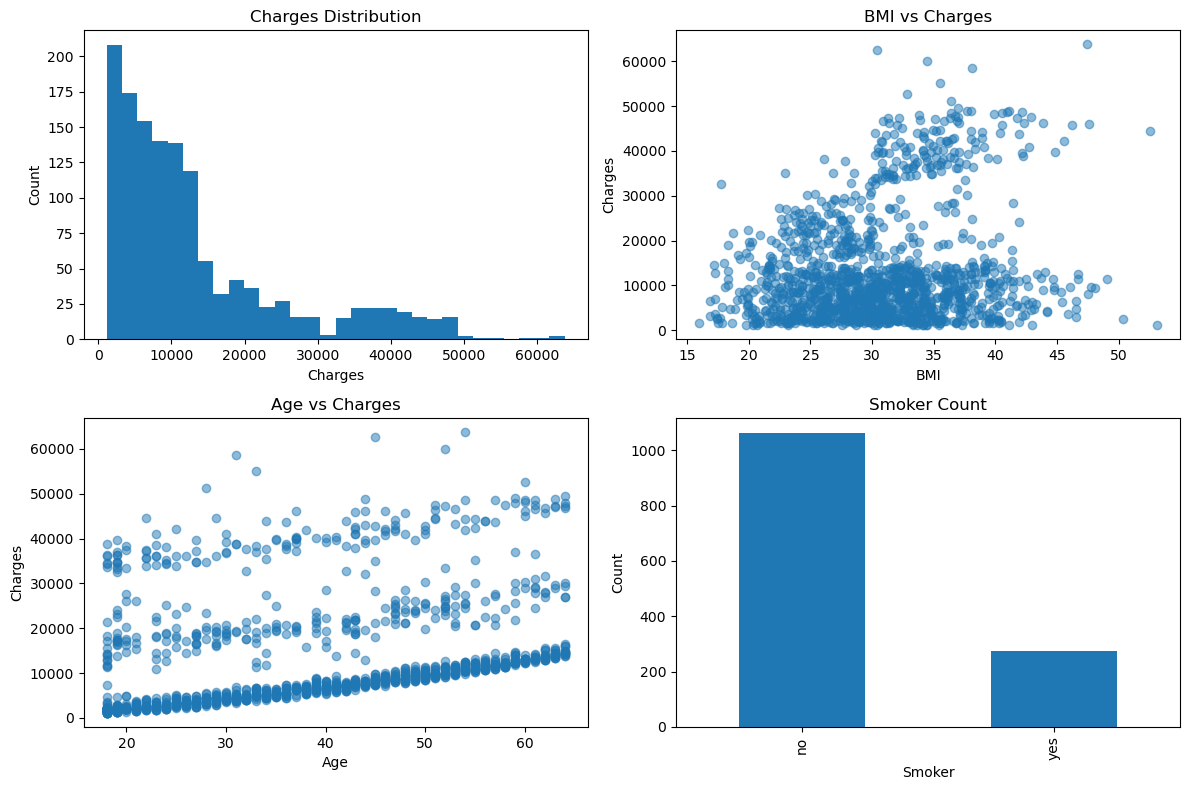

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["charges"], bins=30)
axes[0, 0].set_title("Charges Distribution")
axes[0, 0].set_xlabel("Charges")
axes[0, 0].set_ylabel("Count")

axes[0, 1].scatter(df["bmi"], df["charges"], alpha=0.5)
axes[0, 1].set_title("BMI vs Charges")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Charges")

axes[1, 0].scatter(df["age"], df["charges"], alpha=0.5)
axes[1, 0].set_title("Age vs Charges")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Charges")

df["smoker"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Smoker Count")
axes[1, 1].set_xlabel("Smoker")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Interpretation of the EDA

A few patterns are already visible:
- `charges` are right-skewed, which is common in cost data.
- Higher **BMI** appears to be associated with higher insurance charges.
- Higher **age** tends to correlate with higher charges.
- **Smoker status** is likely to be a strong predictor.

Even simple plots already suggest that a linear model can capture a meaningful baseline signal.

## Data Preprocessing

The preprocessing pipeline includes:
- feature-target split,
- scaling of numerical variables,
- one-hot encoding of categorical variables,
- train-test split.

For this dataset:
- no missing values are present,
- numerical features are standardized with `StandardScaler`,
- categorical features are encoded using `OneHotEncoder`,
- all preprocessing steps are combined into a single `Pipeline` for reproducibility.

### Feature groups
- **Numerical features**: `age`, `bmi`, `children`
- **Categorical features**: `sex`, `smoker`, `region`


In [5]:
X = df.drop(columns=["charges"])
y = df["charges"].astype(float)

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1070, 6)
X_test shape: (268, 6)


## Model Training

A **Linear Regression** model is used as the baseline model for Phase 1.

This is a good choice here because:
- it is simple and interpretable,
- it trains quickly,
- and its coefficients plus intercept can be exported to JSON for browser-side usage.

In [6]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Model Evaluation

The following metrics are used:
- **MAE (Mean Absolute Error)**: average absolute prediction error
- **RMSE (Root Mean Squared Error)**: penalizes larger errors more strongly
- **R²**: explains how much variance of the target is captured by the model

These metrics together provide a balanced view of model performance.

In [7]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 4181.19
RMSE : 5796.28
R²   : 0.7836


## Visual Evaluation

Two diagnostic plots are created:
1. **Residual distribution**  
   Shows whether prediction errors are centered around zero.
2. **Predicted vs Actual**  
   Shows how closely predictions align with true target values.

These visualizations are useful for the notebook documentation and can also be reused later in the web app or report.

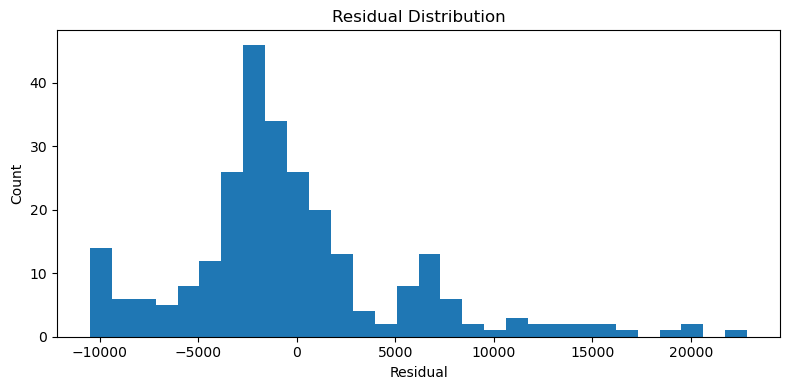

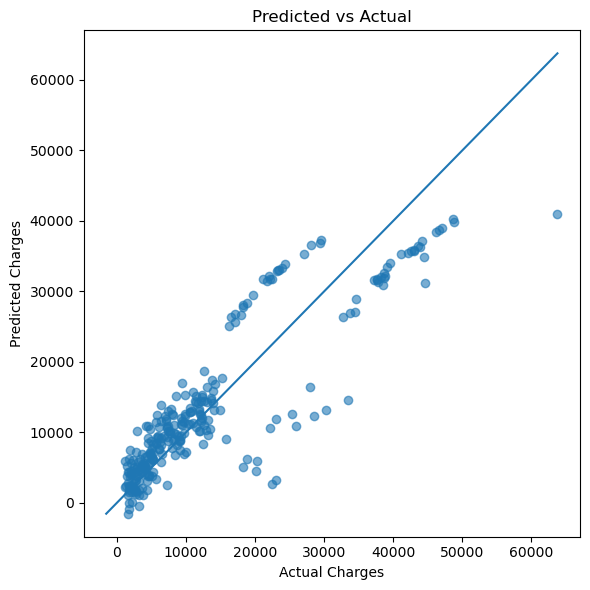

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(DOCS_DIR / "residuals.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high])

plt.title("Predicted vs Actual")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.tight_layout()
plt.savefig(DOCS_DIR / "pred_vs_actual.png", dpi=150)
plt.show()

## Export Model for Browser Prediction

The trained model is exported to a **JSON file** that can be loaded by the static web interface.

Because this project uses preprocessing before the regression step, the export includes:
- numerical feature names,
- scaling means and scales,
- categorical feature names,
- category levels used in one-hot encoding,
- final feature order after preprocessing,
- regression coefficients and intercept,
- evaluation metrics.

This allows the JavaScript frontend to reconstruct the same preprocessing logic before making predictions.

In [9]:
pre = pipeline.named_steps["preprocess"]
reg = pipeline.named_steps["regressor"]

scaler = pre.named_transformers_["num"]
ohe = pre.named_transformers_["cat"]
feature_names_out = list(pre.get_feature_names_out())

model_bundle = {
    "meta": {
        "target": "charges",
        "test_size": 0.2,
        "random_state": 42,
        "metrics_test": {
            "MAE": float(mae),
            "RMSE": float(rmse),
            "R2": float(r2),
        },
    },
    "preprocess": {
        "numeric_features": numeric_features,
        "numeric_mean": scaler.mean_.tolist(),
        "numeric_scale": scaler.scale_.tolist(),
        "categorical_features": categorical_features,
        "categorical_categories": {
            feature: categories.tolist()
            for feature, categories in zip(categorical_features, ohe.categories_)
        },
        "feature_names_out": feature_names_out,
    },
    "model": {
        "intercept": float(reg.intercept_),
        "coef": reg.coef_.tolist(),
    },
}

with open(DOCS_DIR / "model.json", "w", encoding="utf-8") as f:
    json.dump(model_bundle, f, indent=2)

with open(DOCS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(model_bundle["meta"], f, indent=2)

print("Exported files:")
print("-", DOCS_DIR / "model.json")
print("-", DOCS_DIR / "metrics.json")
print("-", DOCS_DIR / "residuals.png")
print("-", DOCS_DIR / "pred_vs_actual.png")

Exported files:
- docs\model.json
- docs\metrics.json
- docs\residuals.png
- docs\pred_vs_actual.png


## Check Exported Model Structure

This small validation step confirms that the exported JSON file was created correctly.

In [10]:
with open(DOCS_DIR / "model.json", "r", encoding="utf-8") as f:
    exported_model = json.load(f)

print("Top-level keys:", exported_model.keys())
print("Model keys:", exported_model["model"].keys())
print("Preprocess keys:", exported_model["preprocess"].keys())
print("Metrics:", exported_model["meta"]["metrics_test"])

Top-level keys: dict_keys(['meta', 'preprocess', 'model'])
Model keys: dict_keys(['intercept', 'coef'])
Preprocess keys: dict_keys(['numeric_features', 'numeric_mean', 'numeric_scale', 'categorical_features', 'categorical_categories', 'feature_names_out'])
Metrics: {'MAE': 4181.194473753651, 'RMSE': 5796.284659276274, 'R2': 0.7835929767120722}


## Web Interface Files

The static Phase 1 web application should include at least:
- `index.html`
- `styles.css`
- `predict.js`
- `model.json`

The browser interface should:
- provide input controls,
- compute predictions,
- display the predicted value,
- use a clean design,
- and load `model.json` via `fetch()`.

The web files are stored in the `docs/` folder so they can be deployed via GitHub Pages using the `/docs` publishing option.

## Deployment via GitHub Pages

The final website should be deployed publicly through **GitHub Pages**, and the public URL should be included in the documentation.

### Suggested Deployment Steps
1. Create a new public GitHub repository.
2. Upload:
   - `phase1.ipynb`
   - `insurance.csv`
   - the full `docs/` folder
3. Open **Settings > Pages**
4. Under **Build and deployment**, choose:
   - **Source**: `Deploy from a branch`
   - **Branch**: `main`
   - **Folder**: `/docs`
5. Save and wait until GitHub publishes the site.
6. Copy the resulting URL into the final documentation.

### URL
`https://sumpfgeist.github.io/model_deployment/`


## Files Produced in Phase 1

This notebook produces the following outputs:
- `docs/model.json` - exported model parameters for browser inference
- `docs/metrics.json` - evaluation summary
- `docs/residuals.png` - residual distribution plot
- `docs/pred_vs_actual.png` - predicted vs actual plot


## Conclusion

In this phase, a complete classical machine learning workflow was built:
- the dataset was explored and inspected,
- numerical and categorical features were preprocessed,
- a linear regression model was trained and evaluated,
- model artifacts were generated,
- and the trained model was exported for browser-based deployment.

This phase demonstrates how a scikit-learn model can be moved from a notebook into a lightweight client-side prediction interface without requiring a backend server.